# Custom artifacts: bring your own model and your own dataset

Most graph benchmarks treat *new model* and *new dataset* as separate workflows. GraphNetz threads both through the same multi-seed, statistically reported pipeline so that whatever you plug in gets per-cell CIs, Holm-corrected pairwise tests, and a critical-difference diagram for free.

This notebook walks through:

1. **Custom models** — three integration paths (decorator, class attribute, inline tuple) on a built-in dataset.
2. **Custom datasets** — wrapping an already-loaded PyG dataset with `task_from_dataset` and running it through `run_benchmark(tasks=[...])`.
3. **Putting it together** — your model on your dataset, multi-seed, with the same report API.

Everything here runs in well under a minute on CPU.

## Setup

We'll use Cora and Karate Club for a tiny end-to-end run. Both ship with PyG.

In [15]:
import warnings

warnings.filterwarnings('ignore')

import torch
from torch_geometric.nn import GCNConv

from graphnetz import (
    GAT,
    GCN,
    GraphSAGE,
    register_model,
    register_task,
    run_benchmark,
    task_from_dataset,
    unregister_task,
)
from graphnetz.benchmark import Task

## 1. Custom models — three integration paths

Models declare which task type they support; the dispatcher skips incompatible (model, task) pairs. Pick whichever style fits how you ship code.

### Path A — decorator (recommended for libraries)

Permanent registration at import time. The model is now visible to every `run_benchmark` call by name.

In [16]:
@register_model(task_type={'node_cls'})
class TinyGCN(torch.nn.Module):
    """Two-layer GCN with no frills."""

    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int) -> None:
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, data):
        x, ei = data.x, data.edge_index
        return self.conv2(torch.relu(self.conv1(x, ei)), ei)

### Path B — class attribute (no decorator)

Same effect, no decorator dependency. Useful when you can't (or don't want to) edit imports at the top of a file.

In [17]:
class AttrGCN(torch.nn.Module):
    task_types = {'node_cls'}

    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int) -> None:
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, data):
        x, ei = data.x, data.edge_index
        return self.conv2(torch.relu(self.conv1(x, ei)), ei)

### Path C — inline tuple (one-shot variants)

When you want two configurations of the same architecture in the same `run_benchmark` call. The third slot is a factory that builds an instance from `(in_channels, hidden_channels, out_channels)`.

In [18]:
class FactoryGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, data):
        x, ei = data.x, data.edge_index
        x = torch.relu(self.conv1(x, ei))
        x = torch.nn.functional.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, ei)

### Run all three custom models on Cora alongside the built-ins

All four sources of models flow through the same `run_benchmark` call. The result is a single `BenchmarkReport` with per-cell mean ± CI and Holm-corrected pairwise tests.

In [19]:
report_models = run_benchmark(
    'social',
    {
        'GCN': GCN,                                          # built-in
        'TinyGCN': TinyGCN,                                  # decorator
        'AttrGCN': AttrGCN,                                  # class attribute
        'FactoryGCN-d0.3': (FactoryGCN, 'node_cls',
                            lambda i, h, o: FactoryGCN(i, h, o, dropout=0.3)),
    },
    only=['cora'],
    seeds=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9),
    epochs=30,
    verbose=False,
)
report_models.summary()

n_seeds    mean       std       sem    ci_low   ci_high
task model                                                                   
cora AttrGCN               10  0.7930  0.004714  0.001491  0.789628  0.796372
     FactoryGCN-d0.3       10  0.7933  0.003773  0.001193  0.790601  0.795999
     GCN                   10  0.7930  0.004714  0.001491  0.789628  0.796372
     TinyGCN               10  0.7930  0.004714  0.001491  0.789628  0.796372

## 2. Custom datasets — bring your own PyG-shaped object

Any dataset that satisfies the standard PyG contract works: an object that supports `ds[0]` and exposes `num_features` / `num_classes` (or `num_relations` for relational LP). Use **`task_from_dataset`** to wrap an already-loaded dataset, or write a loader function for synthetic / on-demand datasets.

### A minimal custom dataset

We build a wrapper around `KarateClub` with explicit train/val/test masks. The wrapper *is* the dataset — no subclassing PyG, no `process()` boilerplate.

In [20]:
from torch_geometric.datasets import KarateClub


class MyKarateDataset:
    """Karate Club with a 50/25/25 node split for node classification."""

    def __init__(self) -> None:
        data = KarateClub()[0]
        n = data.num_nodes
        train = torch.zeros(n, dtype=torch.bool); train[: n // 2] = True
        val   = torch.zeros(n, dtype=torch.bool); val[n // 2 : 3 * n // 4] = True
        test  = torch.zeros(n, dtype=torch.bool); test[3 * n // 4 :] = True
        data.train_mask, data.val_mask, data.test_mask = train, val, test
        self._data = data
        self.num_features = int(data.num_features)
        self.num_classes = int(data.y.max().item()) + 1

    def __getitem__(self, idx):
        if idx != 0:
            raise IndexError(idx)
        return self._data

    def __len__(self):
        return 1

ds = MyKarateDataset()
print(f'features={ds.num_features}, classes={ds.num_classes}, nodes={ds[0].num_nodes}')

features=34, classes=4, nodes=34


### Easy path — `tasks=[Task(...)]` bypasses the registry

No global state to mutate. `category` defaults to `"custom"` and is only used to namespace the cache directory.

In [21]:
task = task_from_dataset('my_karate', 'node_cls', ds, epochs=20)

report_ds = run_benchmark(
    models={'GCN': GCN, 'GAT': GAT, 'GraphSAGE': GraphSAGE},
    tasks=[task],
    seeds=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9),
    verbose=False,
)
report_ds.summary()

n_seeds      mean       std       sem    ci_low   ci_high
task      model                                                               
my_karate GAT             10  0.455556  0.097288  0.030765  0.385960  0.525151
          GCN             10  0.144444  0.105409  0.033333  0.069039  0.219850
          GraphSAGE       10  0.133333  0.114755  0.036289  0.051243  0.215424

### Permanent path — `register_task` adds it to `BENCHMARK_TASKS`

Use this when you want the dataset visible to `run_benchmark(category, ...)` and listed by `iter_benchmark_tasks`. Always pair with `unregister_task` to keep state clean.

In [22]:
register_task('my_lab', task_from_dataset('karate_v2', 'node_cls', ds, epochs=20))

try:
    report_reg = run_benchmark(
        'my_lab',
        {'GCN': GCN},
        seeds=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9),
        verbose=False,
    )
    print(report_reg.summary())
finally:
    unregister_task('my_lab', 'karate_v2')

                 n_seeds      mean       std       sem    ci_low  ci_high
task      model                                                          
karate_v2 GCN         10  0.144444  0.105409  0.033333  0.069039  0.21985


### Seed-aware loaders for synthetic datasets

If your dataset is generated, give the loader a `seed` keyword and the dispatcher will pass the benchmark seed in — so cross-seed variance reflects *both* model init and data resampling.

In [23]:
from torch_geometric.data import Data
from torch_geometric.utils import erdos_renyi_graph


class SyntheticER:
    """Erdos-Renyi node-classification toy: random labels, random structure."""

    def __init__(self, n=64, p=0.1, seed=0) -> None:
        gen = torch.Generator().manual_seed(seed)
        edge_index = erdos_renyi_graph(n, p, directed=False)
        x = torch.randn((n, 8), generator=gen)
        y = torch.randint(0, 3, (n,), generator=gen)
        train = torch.zeros(n, dtype=torch.bool); train[: n // 2] = True
        val   = torch.zeros(n, dtype=torch.bool); val[n // 2 : 3 * n // 4] = True
        test  = torch.zeros(n, dtype=torch.bool); test[3 * n // 4 :] = True
        self._data = Data(x=x, edge_index=edge_index, y=y,
                          train_mask=train, val_mask=val, test_mask=test)
        self.num_features = 8
        self.num_classes = 3

    def __getitem__(self, idx):
        if idx != 0:
            raise IndexError(idx)
        return self._data

    def __len__(self):
        return 1


def synthetic_loader(_root: str, *, seed: int):
    return SyntheticER(n=64, p=0.1, seed=seed)

synthetic_task = Task('synthetic_er', 'node_cls', synthetic_loader, epochs=20)

report_syn = run_benchmark(
    models={'GCN': GCN, 'GAT': GAT},
    tasks=[synthetic_task],
    seeds=(0, 1, 2),
    verbose=False,
)
report_syn.summary()

n_seeds      mean       std      sem    ci_low   ci_high
task         model                                                          
synthetic_er GAT          3  0.354167  0.095470  0.05512  0.117005  0.591328
             GCN          3  0.291667  0.190941  0.11024 -0.182656  0.765990

## 3. Putting it together — custom model on a custom dataset

The whole point of the design: nothing changes in the call shape when you swap the built-ins for your own components. Same multi-seed pipeline, same `BenchmarkReport`.

In [24]:
report_combined = run_benchmark(
    models={
        'GCN':            GCN,
        'TinyGCN':        TinyGCN,
        'FactoryGCN-d.3': (FactoryGCN, 'node_cls',
                           lambda i, h, o: FactoryGCN(i, h, o, dropout=0.3)),
    },
    tasks=[task_from_dataset('my_karate', 'node_cls', ds, epochs=20)],
    seeds=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9),
    verbose=False,
)
print(report_combined.summary())
print()
print(report_combined.pairwise())

                          n_seeds      mean       std       sem    ci_low  \
task      model                                                             
my_karate FactoryGCN-d.3       10  0.044444  0.093697  0.029630 -0.022582   
          GCN                  10  0.144444  0.105409  0.033333  0.069039   
          TinyGCN              10  0.144444  0.105409  0.033333  0.069039   

                           ci_high  
task      model                     
my_karate FactoryGCN-d.3  0.111471  
          GCN             0.219850  
          TinyGCN         0.219850  

        task         model_a  model_b  mean_diff     p_raw    p_holm  \
0  my_karate  FactoryGCN-d.3      GCN       -0.1  0.018719  0.037439   
1  my_karate  FactoryGCN-d.3  TinyGCN       -0.1  0.018719  0.037439   
2  my_karate             GCN  TinyGCN        0.0       NaN       NaN   

   significant  
0         True  
1         True  
2        False  


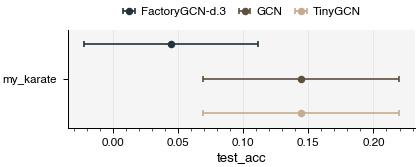

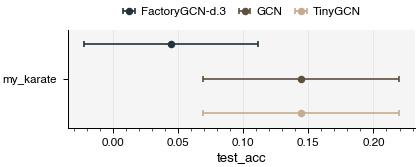

In [25]:
fig, _ = report_combined.plot_forest(ci=0.95)
fig

## What you've seen

- Three ways to plug in a custom model: `@register_model`, `tasks = {...}`, or an inline `(cls, tasks, factory)` tuple.
- Two ways to plug in a custom dataset: ad-hoc `tasks=[task_from_dataset(...)]` for one-off use, `register_task` for permanent inclusion in the curated taxonomy.
- A seed-aware loader for synthetic data, so cross-seed variance captures data resampling rather than model init alone.
- The same `BenchmarkReport` API — `summary`, `pairwise`, `plot_forest`, `plot_critical_difference`, `to_latex` — works on every report regardless of where the model or dataset came from.

For more, see the [Models & adapters](https://github.com/quant-sci/graphnetz/blob/main/docs/models.md) and [Dataset taxonomy](https://github.com/quant-sci/graphnetz/blob/main/docs/datasets.md) pages.